In [4]:
from google.colab import files

uploaded = files.upload()

Saving time_series_60min_singleindex.csv to time_series_60min_singleindex.csv


In [5]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint

pd.set_option('display.max_columns', None)

In [6]:
#dataset load
df = pd.read_csv('time_series_60min_singleindex.csv')

print(df.shape)
df.head()

(50401, 300)


,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,BE_wind_generation_actual,BE_wind_offshore_generation_actual,BE_wind_onshore_generation_actual,BG_load_actual_entsoe_transparency,BG_load_forecast_entsoe_transparency,BG_solar_generation_actual,BG_wind_onshore_generation_actual,CH_load_actual_entsoe_transparency,CH_load_forecast_entsoe_transparency,CH_solar_capacity,CH_solar_generation_actual,CH_wind_onshore_capacity,CH_wind_onshore_generation_actual,CY_load_actual_entsoe_transparency,CY_load_forecast_entsoe_transparency,CY_wind_onshore_generation_actual,CZ_load_actual_entsoe_transparency,CZ_load_forecast_entsoe_transparency,CZ_solar_generation_actual,CZ_wind_onshore_generation_actual,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,DE_wind_offshore_profile,DE_wind_onshore_capacity,DE_wind_onshore_generation_actual,DE_wind_onshore_profile,DE_50hertz_load_actual_entsoe_transparency,DE_50hertz_load_forecast_entsoe_transparency,DE_50hertz_solar_generation_actual,DE_50hertz_wind_generation_actual,DE_50hertz_wind_offshore_generation_actual,DE_50hertz_wind_onshore_generation_actual,DE_LU_load_actual_entsoe_transparency,DE_LU_load_forecast_entsoe_transparency,DE_LU_price_day_ahead,DE_LU_solar_generation_actual,DE_LU_wind_generation_actual,DE_LU_wind_offshore_generation_actual,DE_LU_wind_onshore_generation_actual,DE_amprion_load_actual_entsoe_transparency,DE_amprion_load_forecast_entsoe_transparency,DE_amprion_solar_generation_actual,DE_amprion_wind_onshore_generation_actual,DE_tennet_load_actual_entsoe_transparency,DE_tennet_load_forecast_entsoe_transparency,DE_tennet_solar_generation_actual,DE_tennet_wind_generation_actual,DE_tennet_wind_offshore_generation_actual,DE_tennet_wind_onshore_generation_actual,DE_transnetbw_load_actual_entsoe_transparency,DE_transnetbw_load_forecast_entsoe_transparency,DE_transnetbw_solar_generation_actual,DE_transnetbw_wind_onshore_generation_actual,DK_load_actual_entsoe_transparency,DK_load_forecast_entsoe_transparency,DK_solar_capacity,DK_solar_generation_actual,DK_wind_capacity,DK_wind_generation_actual,DK_wind_offshore_capacity,DK_wind_offshore_generation_actual,DK_wind_onshore_capacity,DK_wind_onshore_generation_actual,DK_1_load_actual_entsoe_transparency,DK_1_load_forecast_entsoe_transparency,DK_1_price_day_ahead,DK_1_solar_generation_actual,DK_1_wind_generation_actual,DK_1_wind_offshore_generation_actual,DK_1_wind_onshore_generation_actual,DK_2_load_actual_entsoe_transparency,DK_2_load_forecast_entsoe_transparency,DK_2_price_day_ahead,DK_2_solar_generation_actual,DK_2_wind_generation_actual,DK_2_wind_offshore_generation_actual,DK_2_wind_onshore_generation_actual,EE_load_actual_entsoe_transparency,EE_load_forecast_entsoe_transparency,EE_solar_generation_actual,EE_wind_onshore_generation_actual,ES_load_actual_entsoe_transparency,ES_load_forecast_entsoe_transparency,ES_solar_generation_actual,ES_wind_onshore_generation_actual,FI_load_actual_entsoe_transparency,FI_load_forecast_entsoe_transparency,FI_wind_onshore_generation_actual,FR_load_actual_entsoe_transparency,FR_load_forecast_entsoe_transparency,FR_solar_generation_actual,FR_wind_onshore_generation_actual,GB_GBN_load_actual_entsoe_transparency,GB_GBN_load_forecast_entsoe_transparency,GB_GBN_price_day_ahead,GB_GBN_solar_capacity,GB_GBN_solar_generation_actual,GB_GBN_solar_profile,GB_GBN_wind_capacity,GB_GBN_wind_generation_actual,GB_GBN_wind_profile,GB_GBN_wind_offshore_capacity,GB_GBN_wind_offshore_generation_actual,GB_GBN_wind_offshore_profile,GB_GBN_wind_onshore_capacity,GB_GBN_wind_onshore_generation_actual,GB_G

In [7]:
#finding markets with day-ahead prices
price_cols = [c for c in df.columns if 'price_day_ahead' in c]

for col in price_cols:
    print(col)

AT_price_day_ahead
DE_LU_price_day_ahead
DK_1_price_day_ahead
DK_2_price_day_ahead
GB_GBN_price_day_ahead
IE_sem_price_day_ahead
IT_BRNN_price_day_ahead
IT_CNOR_price_day_ahead
IT_CSUD_price_day_ahead
IT_FOGN_price_day_ahead
IT_GR_price_day_ahead
IT_NORD_price_day_ahead
IT_NORD_AT_price_day_ahead
IT_NORD_CH_price_day_ahead
IT_NORD_FR_price_day_ahead
IT_NORD_SI_price_day_ahead
IT_PRGP_price_day_ahead
IT_ROSN_price_day_ahead
IT_SACO_AC_price_day_ahead
IT_SACO_DC_price_day_ahead
IT_SARD_price_day_ahead
IT_SICI_price_day_ahead
IT_SUD_price_day_ahead
NO_1_price_day_ahead
NO_2_price_day_ahead
NO_3_price_day_ahead
NO_4_price_day_ahead
NO_5_price_day_ahead
SE_1_price_day_ahead
SE_2_price_day_ahead
SE_3_price_day_ahead
SE_4_price_day_ahead


In [8]:
price_cols = [c for c in df.columns if 'price_day_ahead' in c]

for col in price_cols:
    print(col,
          df[col].notna().sum())

AT_price_day_ahead 32845
DE_LU_price_day_ahead 17540
DK_1_price_day_ahead 50386
DK_2_price_day_ahead 50386
GB_GBN_price_day_ahead 50290
IE_sem_price_day_ahead 17515
IT_BRNN_price_day_ahead 34958
IT_CNOR_price_day_ahead 50267
IT_CSUD_price_day_ahead 50267
IT_FOGN_price_day_ahead 34934
IT_GR_price_day_ahead 25527
IT_NORD_price_day_ahead 50265
IT_NORD_AT_price_day_ahead 25576
IT_NORD_CH_price_day_ahead 25527
IT_NORD_FR_price_day_ahead 25576
IT_NORD_SI_price_day_ahead 25576
IT_PRGP_price_day_ahead 34958
IT_ROSN_price_day_ahead 50267
IT_SACO_AC_price_day_ahead 50267
IT_SACO_DC_price_day_ahead 50243
IT_SARD_price_day_ahead 50267
IT_SICI_price_day_ahead 50267
IT_SUD_price_day_ahead 50267
NO_1_price_day_ahead 50386
NO_2_price_day_ahead 50386
NO_3_price_day_ahead 50362
NO_4_price_day_ahead 50386
NO_5_price_day_ahead 50386
SE_1_price_day_ahead 50386
SE_2_price_day_ahead 50362
SE_3_price_day_ahead 50386
SE_4_price_day_ahead 50386


In [9]:
counts = {}

for col in price_cols:
    counts[col] = df[col].notna().sum()

counts = pd.Series(counts)

print(
    counts.sort_values(
        ascending=False
    )
)

DK_2_price_day_ahead          50386
DK_1_price_day_ahead          50386
NO_2_price_day_ahead          50386
SE_1_price_day_ahead          50386
SE_4_price_day_ahead          50386
SE_3_price_day_ahead          50386
NO_5_price_day_ahead          50386
NO_1_price_day_ahead          50386
NO_4_price_day_ahead          50386
NO_3_price_day_ahead          50362
SE_2_price_day_ahead          50362
GB_GBN_price_day_ahead        50290
IT_CSUD_price_day_ahead       50267
IT_SUD_price_day_ahead        50267
IT_SACO_AC_price_day_ahead    50267
IT_CNOR_price_day_ahead       50267
IT_ROSN_price_day_ahead       50267
IT_SICI_price_day_ahead       50267
IT_SARD_price_day_ahead       50267
IT_NORD_price_day_ahead       50265
IT_SACO_DC_price_day_ahead    50243
IT_BRNN_price_day_ahead       34958
IT_PRGP_price_day_ahead       34958
IT_FOGN_price_day_ahead       34934
AT_price_day_ahead            32845
IT_NORD_AT_price_day_ahead    25576
IT_NORD_FR_price_day_ahead    25576
IT_NORD_SI_price_day_ahead  

DK_1_price_day_ahead
DK_2_price_day_ahead

Γιατί;

ανήκουν στην ίδια χώρα,
έχουν σχεδόν ίδιο regulatory framework,
είναι διασυνδεδεμένες,
έχουν πλήρες ιστορικό,
είναι ιδανικό παράδειγμα cointegration.

In [10]:
#pair creation
pair = df[
    [
        'utc_timestamp',
        'DK_1_price_day_ahead',
        'DK_2_price_day_ahead'
    ]
].copy()

pair.columns = [
    'date',
    'dk1',
    'dk2'
]

pair['date'] = pd.to_datetime(
    pair['date'],
    utc=True
)

pair = pair.set_index('date')

pair = pair.dropna()

print(pair.shape)

pair.head()

(50386, 2)


,dk1,dk2
date,,
2015-01-01 01:00:00+00:00,16.04,16.04
2015-01-01 02:00:00+00:00,14.60,14.60
2015-01-01 03:00:00+00:00,14.95,14.95
2015-01-01 04:00:00+00:00,14.50,14.50
2015-01-01 05:00:00+00:00,10.76,10.76


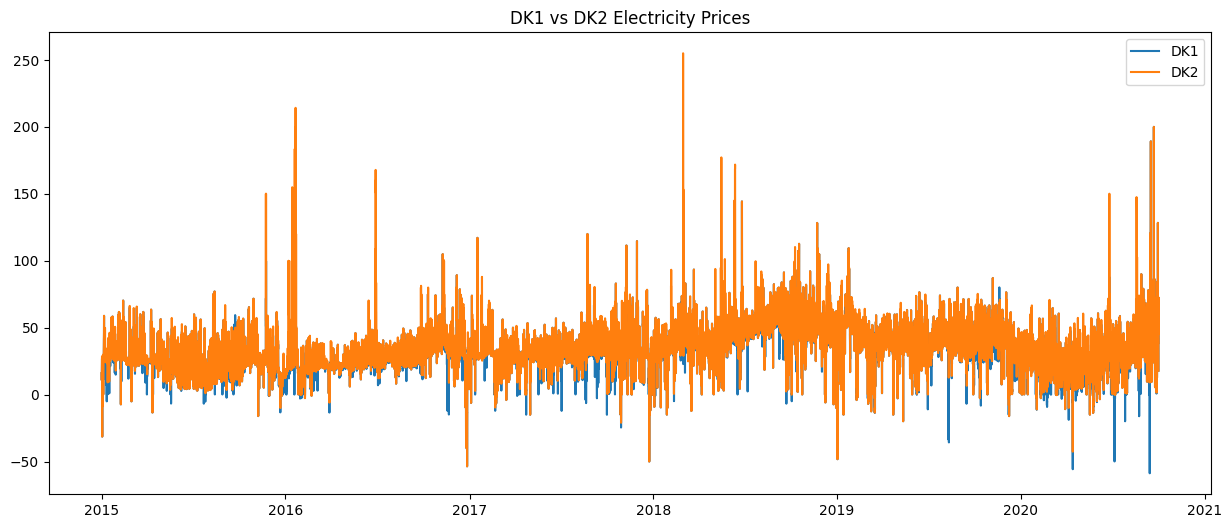

In [11]:
#plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    pair['dk1'],
    label='DK1'
)

plt.plot(
    pair['dk2'],
    label='DK2'
)

plt.legend()

plt.title(
    'DK1 vs DK2 Electricity Prices'
)

plt.show()

In [12]:
#correlation
pair.corr()

,dk1,dk2
dk1,1.000000,0.908819
dk2,0.908819,1.000000


In [13]:
#pearson
from scipy.stats import pearsonr

corr, p = pearsonr(
    pair['dk1'],
    pair['dk2']
)

print(corr)
print(p)

0.9088192733781395
0.0


In [14]:
#cointegration
from statsmodels.tsa.stattools import coint

score, pvalue, critical = coint(
    pair['dk1'],
    pair['dk2']
)

print(score)
print(pvalue)
print(critical)

-21.37890010697206
0.0
[-3.89665738 -3.33625127 -3.04453418]


In [15]:
#OLS Hedge Ratio
import statsmodels.api as sm

X = sm.add_constant(
    pair['dk2']
)

model = sm.OLS(
    pair['dk1'],
    X
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    dk1   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                 2.391e+05
Date:                Thu, 02 Jul 2026   Prob (F-statistic):               0.00
Time:                        16:45:57   Log-Likelihood:            -1.6339e+05
No. Observations:               50386   AIC:                         3.268e+05
Df Residuals:                   50384   BIC:                         3.268e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6842      0.065     41.446      0.0

In [16]:
#spread
beta = model.params['dk2']

spread = (
    pair['dk1']
    - beta*pair['dk2']
)

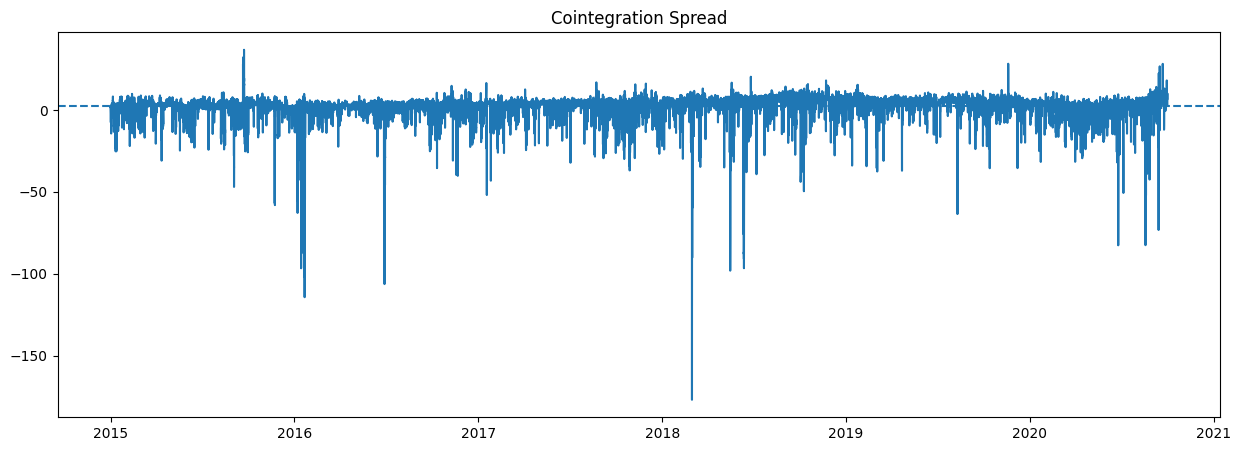

In [17]:
#plot of spread
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(spread)

plt.axhline(
    spread.mean(),
    linestyle='--'
)

plt.title(
    'Cointegration Spread'
)

plt.show()

In [18]:
#adf test on spread
from statsmodels.tsa.stattools import adfuller

adf = adfuller(
    spread.dropna()
)

print(
    "ADF Statistic:",
    adf[0]
)

print(
    "P-value:",
    adf[1]
)

ADF Statistic: -21.37868252381813
P-value: 0.0


In [19]:
#hurst exponent
def hurst(ts):
    lags = range(2,100)
    tau = [np.sqrt(np.std(np.subtract(ts[lag:], ts[:-lag])))
           for lag in lags]

    poly = np.polyfit(np.log(lags),
                      np.log(tau),1)

    return poly[0]*2

print(
    "Hurst:",
    hurst(spread.values)
)

Hurst: 0.08169660300767423


In [20]:
#Half-life estimation
spread_lag = spread.shift(1)

spread_ret = spread - spread_lag

spread_lag = spread_lag.dropna()
spread_ret = spread_ret.dropna()

spread_ret = spread_ret.loc[spread_lag.index]

X = sm.add_constant(spread_lag)

model = sm.OLS(
    spread_ret,
    X
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     4115.
Date:                Thu, 02 Jul 2026   Prob (F-statistic):               0.00
Time:                        16:46:32   Log-Likelihood:            -1.3125e+05
No. Observations:               50385   AIC:                         2.625e+05
Df Residuals:                   50383   BIC:                         2.625e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4054      0.016     25.502      0.0

In [21]:
#half-life calculation
lambda_coef = model.params.iloc[1]

half_life = -np.log(2)/lambda_coef

print("Lambda:", lambda_coef)
print("Half-life:", half_life)

Lambda: -0.1510215815619377
Half-life: 4.589722696525121


In [22]:
#Rolling Z-score
lookback = int(round(half_life))

rolling_mean = spread.rolling(
    lookback
).mean()

rolling_std = spread.rolling(
    lookback
).std()

zscore = (
    spread
    - rolling_mean
) / rolling_std

print(zscore.describe())

count    50382.000000
mean        -0.081135
std          1.097162
min         -1.788854
25%         -1.078387
50%         -0.146981
75%          0.907869
max          1.788854
dtype: float64


In [23]:
#trading signals
signals = pd.DataFrame(
    index=spread.index
)

signals['spread'] = spread
signals['zscore'] = zscore

signals['long'] = (
    zscore < -2
).astype(int)

signals['short'] = (
    zscore > 2
).astype(int)

signals['exit'] = (
    abs(zscore) < 0.5
).astype(int)

signals.head()

,spread,zscore,long,short,exit
date,,,,,
2015-01-01 01:00:00+00:00,2.265001,NaN,0,0,0
2015-01-01 02:00:00+00:00,2.061659,NaN,0,0,0
2015-01-01 03:00:00+00:00,2.111082,NaN,0,0,0
2015-01-01 04:00:00+00:00,2.047538,NaN,0,0,0
2015-01-01 05:00:00+00:00,1.519414,-1.703553,0,0,0


In [24]:
#position creation
position = []

pos = 0

for i in range(len(signals)):

    if signals['long'].iloc[i] == 1:
        pos = 1

    elif signals['short'].iloc[i] == 1:
        pos = -1

    elif signals['exit'].iloc[i] == 1:
        pos = 0

    position.append(pos)

signals['position'] = position

In [25]:
#calculation of returns
signals['spread_return'] = spread.diff()

signals['strategy_return'] = (
    signals['position']
    .shift(1)
    *
    signals['spread_return']
)

signals = signals.dropna()

In [26]:
#performance check
cumret = (
    1
    + signals['strategy_return']
).cumprod()

sharpe = (
    signals['strategy_return'].mean()
    /
    signals['strategy_return'].std()
) * np.sqrt(24*365)

print("Sharpe:", sharpe)

print(
    "Total Return:",
    cumret.iloc[-1]
)

Sharpe: nan
Total Return: 1.0


/tmp/ipykernel_13931/1207185419.py:8: RuntimeWarning: invalid value encountered in scalar divide
  signals['strategy_return'].mean()


In [27]:
#maximum drawdown
running_max = cumret.cummax()

drawdown = (
    cumret
    -
    running_max
) / running_max

print(
    "Maximum Drawdown:",
    drawdown.min()
)

Maximum Drawdown: 0.0


In [28]:
#optimization
print(signals['position'].value_counts())

position
0    50382
Name: count, dtype: int64


In [29]:
lookback = 24
rolling_mean = spread.rolling(lookback).mean()
rolling_std = spread.rolling(lookback).std()

zscore = (spread - rolling_mean) / rolling_std

print(zscore.describe())

count    50363.000000
mean        -0.034051
std          1.149049
min         -4.692527
25%         -0.659368
50%          0.198735
75%          0.682971
max          4.685513
dtype: float64


In [30]:
#change thresholds
signals['long'] = (
    zscore < -1.5
).astype(int)

signals['short'] = (
    zscore > 1.5
).astype(int)

signals['exit'] = (
    abs(zscore) < 0.5
).astype(int)

In [31]:
print(signals['long'].sum())
print(signals['short'].sum())

5118
2337


In [32]:
#positions
position = []
pos = 0

for i in range(len(signals)):

    if signals['long'].iloc[i] == 1:
        pos = 1

    elif signals['short'].iloc[i] == 1:
        pos = -1

    elif signals['exit'].iloc[i] == 1:
        pos = 0

    position.append(pos)

signals['position'] = position


In [33]:
#strategy returns
signals['spread_return'] = (
    spread.pct_change()
)

signals['strategy_return'] = (
    signals['position'].shift(1)
    * signals['spread_return']
)

signals = signals.dropna()

In [34]:
#cumulative returns
signals['cum_return'] = (
    1 + signals['strategy_return']
).cumprod()

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)


In [35]:
#sharpe ratio
sharpe = (
    signals['strategy_return'].mean()
    /
    signals['strategy_return'].std()
) * np.sqrt(24*365)

print(sharpe)

nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


In [36]:
#maximum drawdown
running_max = (
    signals['cum_return']
    .cummax()
)

drawdown = (
    signals['cum_return']
    -
    running_max
) / running_max

max_dd = drawdown.min()

print(max_dd)

-785.597513938203


In [38]:
print(
    signals['cum_return'].iloc[-1]
)

nan


In [39]:
#extra metrics
print(
    "Total Return:",
    signals['cum_return'].iloc[-1]
)

print(
    "Number of Long Trades:",
    signals['long'].sum()
)

print(
    "Number of Short Trades:",
    signals['short'].sum()
)

print(
    "Total Positions:",
    (signals['position'] != 0).sum()
)

Total Return: nan
Number of Long Trades: 5116
Number of Short Trades: 2337
Total Positions: 14839


In [40]:
pair['ret_dk1'] = pair['dk1'].diff()
pair['ret_dk2'] = pair['dk2'].diff()

signals['strategy_return'] = (
    signals['position'].shift(1)
    *
    (
        pair['ret_dk1']
        -
        beta*pair['ret_dk2']
    )
)

signals = signals.dropna()

In [41]:
sharpe = (
    signals['strategy_return'].mean()
    /
    signals['strategy_return'].std()
) * np.sqrt(24*365)

print(sharpe)

8.7970035167724


In [42]:
signals['equity_curve'] = (
    signals['strategy_return']
    .cumsum()
)

print(
    signals['equity_curve'].iloc[-1]
)

4202.512686648338


In [43]:
running_max = (
    signals['equity_curve']
    .cummax()
)

drawdown = (
    signals['equity_curve']
    -
    running_max
)

print(
    drawdown.min()
)

-65.25490332288882


Quant Grid Search Optimizer

In [44]:
results = []

lookbacks = [4,6,8,12,24,48]
entries = [0.75,1,1.25,1.5,1.75,2]
exits = [0.1,0.25,0.5,0.75]

for lookback in lookbacks:

    rolling_mean = spread.rolling(
        lookback
    ).mean()

    rolling_std = spread.rolling(
        lookback
    ).std()

    zscore = (
        spread
        - rolling_mean
    ) / rolling_std

    for entry in entries:

        for exit in exits:

            position = []

            pos = 0

            for z in zscore:

                if pd.isna(z):
                    position.append(pos)
                    continue

                if z < -entry:
                    pos = 1

                elif z > entry:
                    pos = -1

                elif abs(z) < exit:
                    pos = 0

                position.append(pos)

            position = pd.Series(
                position,
                index=spread.index
            )

            pnl = (
                position.shift(1)
                *
                (
                    pair['dk1'].diff()
                    -
                    beta*pair['dk2'].diff()
                )
            )

            pnl = pnl.dropna()

            if pnl.std() == 0:
                continue

            sharpe = (
                pnl.mean()
                /
                pnl.std()
            ) * np.sqrt(24*365)

            equity = pnl.cumsum()

            dd = (
                equity
                -
                equity.cummax()
            ).min()

            results.append([
                lookback,
                entry,
                exit,
                sharpe,
                dd,
                equity.iloc[-1]
            ])

In [45]:
results = pd.DataFrame(
    results,
    columns=[
        'lookback',
        'entry',
        'exit',
        'sharpe',
        'drawdown',
        'profit'
    ]
)

results = results.sort_values(
    'sharpe',
    ascending=False
)

results.head(20)

,lookback,entry,exit,sharpe,drawdown,profit
90,24,0.75,0.50,11.777757,-155.377744,18179.526504
89,24,0.75,0.25,11.550611,-155.377744,19025.509074
114,48,0.75,0.50,11.338866,-155.377744,17145.404244
88,24,0.75,0.10,11.269238,-159.313620,19270.247780
94,24,1.00,0.50,10.925422,-155.377744,15972.142148
91,24,0.75,0.75,10.826519,-155.377744,15948.134367
113,48,0.75,0.25,10.781420,-155.377744,17464.119191
115,48,0.75,0.75,10.697382,-155.377744,15724.391675
95,24,1.00,0.75,10.491553,-155.377744,14743.496053
118,48,1.00,0.50,10.312778,-155.377744,15043.680780


In-Sample / Out-of-Sample Test

In [46]:
print(pair.index.min())
print(pair.index.max())

2015-01-01 01:00:00+00:00
2020-09-30 22:00:00+00:00


In [48]:
train = pair.loc[:'2018-12-31']
test = pair.loc['2019-01-01':]

print(train.shape)
print(test.shape)

(35055, 4)
(15331, 4)


In [49]:
#re-estimate beta only in train
import statsmodels.api as sm

X = sm.add_constant(train['dk2'])

model_train = sm.OLS(
    train['dk1'],
    X
).fit()

beta_train = model_train.params['dk2']

print(beta_train)

0.8244139913603566


In [50]:
#spread creation in test
spread_test = (
    test['dk1']
    - beta_train*test['dk2']
)

In [52]:
#we are choosing the best parameters
lookback = 24
entry = 0.75
exit = 0.50

#z-score
rolling_mean = spread_test.rolling(
    lookback
).mean()

rolling_std = spread_test.rolling(
    lookback
).std()

zscore = (
    spread_test
    - rolling_mean
) / rolling_std

In [53]:
#generate positions
position = []

pos = 0

for z in zscore:

    if pd.isna(z):
        position.append(pos)
        continue

    if z < -entry:
        pos = 1

    elif z > entry:
        pos = -1

    elif abs(z) < exit:
        pos = 0

    position.append(pos)

position = pd.Series(
    position,
    index=test.index
)

In [54]:
#PnL
pnl = (
    position.shift(1)
    *
    (
        test['dk1'].diff()
        -
        beta_train*test['dk2'].diff()
    )
)

pnl = pnl.dropna()

In [55]:
#Out-of-sample performance
sharpe = (
    pnl.mean()
    /
    pnl.std()
) * np.sqrt(24*365)

equity = pnl.cumsum()

drawdown = (
    equity
    -
    equity.cummax()
).min()

print("Out-of-sample Sharpe:", sharpe)
print("Out-of-sample Drawdown:", drawdown)
print("Out-of-sample Profit:", equity.iloc[-1])

Out-of-sample Sharpe: 12.97923926694449
Out-of-sample Drawdown: -67.37954886440616
Out-of-sample Profit: 5328.10203961872


In [56]:
#Transaction Cost Analysis
cost_per_trade = 0.5
trades = position.diff().abs()

transaction_cost = trades * cost_per_trade

pnl_net = pnl - transaction_cost

In [57]:
sharpe_net = (
    pnl_net.mean()
    /
    pnl_net.std()
) * np.sqrt(24*365)

equity_net = pnl_net.cumsum()

dd_net = (
    equity_net
    -
    equity_net.cummax()
).min()

print(sharpe_net)
print(dd_net)
print(equity_net.iloc[-1])

9.114091346743704
-67.87954886440627
3641.6020396187037
